# Understanding the image-neural dataloader

This tutorial follows one presentation from the raw MATLAB raster to the tensor returned by `NeuralInputDataset`. It answers two concrete questions:

1. **Does the image paired with a trial have the correct identity?**
2. **Is the neural target exactly the response in the raster after the requested channel selection, time crop, and temporal binning?**
3. **After averaging repetitions, do the neural and saved DNN representations show the expected static-to-dynamic association?**

The repeated `raster` is used here, not `natraster`. Each sample is therefore one presentation of an image; different repetitions of the same image remain separate samples.

> Important: values in this raster are continuous, signed, preprocessed multi-unit responses. They are not binary spike events. The plots below therefore show response values, not spike ticks.

## Axis ledger

The same response changes axis order as it moves through the pipeline:

| Stage | Shape | Meaning |
|---|---|---|
| raw HDF5 `rasters` | `[trials, source_time, source_channels]` | one row per presentation at the original sampling rate |
| `load_img_raster(...).get_array()` | `[neurons, time, trials]` | cropped, area-selected, optionally binned response |
| `NeuralInputDataset[trial][1]` | `[time, neurons]` | target for one presentation |
| one DataLoader target batch | `[batch, time, neurons]` | stacked presentation targets |

The dataset does **not** average repetitions or fit normalization statistics itself. This tutorial optionally preprocesses the `[neurons, time, trials]` array before passing it to `NeuralInputDataset`; the dataset then only applies `transpose(2, 1, 0)` and converts to `float32`.

In [ ]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from torchvision import transforms
from torchvision.datasets import ImageFolder

# Locate the repository whether Jupyter starts at the root or scripts/.
cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in [cwd, *cwd.parents] if (path / "config.yaml").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the project config.yaml.")
# end if the project root is unavailable

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as file:
    config = yaml.safe_load(file)
# end with project configuration
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])

from project_specific_utils.dataloader import (  # noqa: E402
    BrainAreas,
    NeuralInputDataset,
    apply_neural_preprocessing,
    fit_neural_preprocessing,
    load_img_natraster,
    load_img_raster,
    make_neural_input_loader,
    map_image_order_from_ann_to_monkey,
    map_trial_image_order_to_ann,
)
from IT_recap.hf_feature_extraction import load_hf_layer_features  # noqa: E402
from IT_recap.neural_prediction_training import (  # noqa: E402
    split_half_reliability,
)
from IT_recap.static_drsa import compute_static_drsa  # noqa: E402

In [ ]:
@dataclass
class Cfg:
    # Repeated single-trial neural data.
    monkey_name: str = "three0"
    brain_area: str = "AIT"
    raster_file: str = "rasters_three0_250313to21.mat"
    raster_key: str = "rasters"
    image_names_file: str = "allimages_three0_250313to21.mat"
    image_names_key: str = "allimages"
    original_fs: int = 1000
    new_fs: int = 100
    time_start_ms: float = 0.0
    time_end_ms: float = 300.0
    raster_chunk_size: int = 512

    # Optional target preprocessing fitted across tutorial samples.
    center_neural_features: bool = False
    robust_minmax_neurons: bool = False
    robust_percentile_range: tuple[float, float] = (1.0, 99.0)
    clip_robust_minmax: bool = True

    # Image source used by the ANN and by the paired dataset.
    folder_name: str = "talia_20each_tizi"

    # Select an image explicitly, or use the strongest repeated response.
    example_image: int | str | None = "camera_04.jpg"
    example_repetition_index: int = 0
    n_high_activity_images_to_list: int = 10
    example_neuron_index: int = 0  # local index within brain_area
    batch_size: int = 8
    n_example_repetitions: int = 4
    n_consistent_channels: int = 5
    self_consistency_resamples: int = 40
    validation_fraction: float = 0.2
    random_seed: int = 0

    # Optional averaged-response comparison at the end.
    natraster_date: str = "250313"

    # Static DNN layers compared with the averaged dynamic neural response.
    model_name: str = "dino_v3_l"
    model_img_size: int = 224
    model_pooling: str = "mean"
    model_layer_names: tuple[str, ...] = (
        "layer.3.mlp.down_proj",
        "layer.13.mlp.down_proj",
        "layer.16.mlp.down_proj",
        "layer.20.mlp.down_proj",
    )
    training_input_mode: str = "activations"
    model_batch_size: int = 64
    signal_RDM_metric: str = "cosine_cnt"
    model_RDM_metric: str = "cosine_cnt"
    RSA_metric: str = "spearman"
    alignment_shuffle_seed: int = 0
    heatmap_cmap: str = "viridis"
    layer_line_cmap: str = "turbo"


cfg = Cfg()
cfg

## 1. Inspect the source files without loading the full raster

MATLAB v7.3 files are HDF5 files. The repeated response file is stored as `[trials, time, channels]`; the companion file contains one image filename for every trial. This first check is deliberately independent of the project loader.

In [3]:
data_dir = Path(paths["data_path"]) / "data"
raster_path = data_dir / cfg.raster_file
image_names_path = data_dir / cfg.image_names_file

with h5py.File(raster_path, "r") as h5file:
    raw_shape = h5file[cfg.raster_key].shape
    raw_dtype = h5file[cfg.raster_key].dtype
# end with raw raster file

with h5py.File(image_names_path, "r") as h5file:
    image_name_shape = h5file[cfg.image_names_key].shape
# end with image-name file

if raw_shape[0] != image_name_shape[0]:
    raise ValueError("The raw trials and per-trial image names do not align.")
# end if the source files disagree

print(f"raw raster [trials, source_time, source_channels]: {raw_shape}")
print(f"raw dtype: {raw_dtype}")
print(f"per-trial image names: {image_name_shape}")

raw raster [trials, source_time, source_channels]: (14840, 500, 383)
raw dtype: float32
per-trial image names: (14840, 1)


## 2. Load the repeated raster

`load_img_raster` performs four scientifically relevant operations:

1. crops the source time axis;
2. selects and concatenates the channel ranges assigned to the requested brain area;
3. averages non-overlapping temporal bins when `new_fs < original_fs`;
4. changes the axis order to `[neurons, time, trials]`.

For 1000 → 100 Hz, every output value is the mean of 10 consecutive source samples. Cropping happens before binning.

The configuration can additionally center every `(neuron, time-bin)` feature across samples and robustly min-max scale each neuron using percentiles pooled across time and samples. Centering is applied first. This tutorial fits on all loaded samples for visualization; a predictive experiment should fit on training samples only, as done in `noise_layer_baseline_model_dev.ipynb`.

In [ ]:
raster, trial_image_names = load_img_raster(
    paths=paths,
    monkey_name=cfg.monkey_name,
    raster_file=cfg.raster_file,
    image_names_file=cfg.image_names_file,
    raster_key=cfg.raster_key,
    image_names_key=cfg.image_names_key,
    original_fs=cfg.original_fs,
    new_fs=cfg.new_fs,
    time_start_ms=cfg.time_start_ms,
    time_end_ms=cfg.time_end_ms,
    brain_area=cfg.brain_area,
    chunk_size=cfg.raster_chunk_size,
)
raw_raster_array = raster.get_array()
neural_preprocessing_stats = fit_neural_preprocessing(
    raw_raster_array,
    center_features=cfg.center_neural_features,
    robust_minmax_neurons=cfg.robust_minmax_neurons,
    robust_percentile_range=cfg.robust_percentile_range,
    clip_robust_minmax=cfg.clip_robust_minmax,
)
raster_array = apply_neural_preprocessing(
    raw_raster_array,
    neural_preprocessing_stats,
)

if len(trial_image_names) != raster_array.shape[2]:
    raise ValueError("Every loaded neural trial must have one image name.")
# end if trial metadata and responses disagree

print(f"loaded raster [neurons, time, trials]: {raster_array.shape}")
print(
    "neural preprocessing: "
    f"center_features={cfg.center_neural_features}, "
    f"robust_minmax_neurons={cfg.robust_minmax_neurons}, "
    f"percentiles={cfg.robust_percentile_range}"
)
print(f"loaded sampling frequency: {raster.fs} Hz")
print(f"first five source image names: {trial_image_names[:5]}")
print(f"unique stimuli: {len(set(trial_image_names))}")

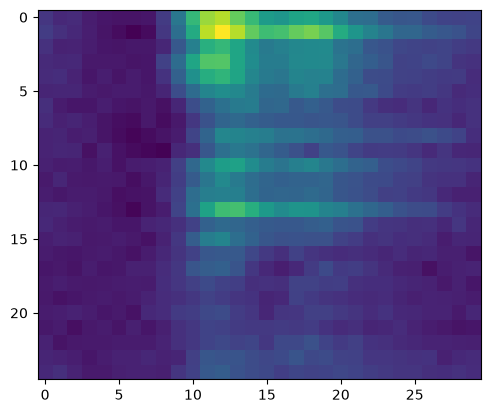

In [32]:
plt.imshow(np.mean(raster, axis=2).T)

## 3. Map each neural trial to the correct image

`ImageFolder` defines the source order used when images or saved ANN activations are indexed. Neural trials occur in a different order and contain repetitions.

`image_indices[trial_index]` is therefore the `ImageFolder` row for that neural trial. Repeated occurrences of one stimulus have the same image index but different neural targets. The mapping uses filenames, not class labels.

This tutorial uses only `ToTensor()` so the paired image can be displayed directly. Replace that transform with the model-specific resize and normalization when training; doing so changes the image tensor but not its neural pairing.

Set `cfg.example_image` to an `ImageFolder` index or a quoted filename to inspect a specific image. With a value of `None`, the notebook ranks repeated images by the RMS magnitude of their repetition-averaged population response and selects the strongest one. The printed candidate table provides both indices and filenames. `cfg.example_repetition_index` selects which presentation supplies the single-trial audit.

In [5]:
stimuli_root = Path(paths["livingstone_lab"]) / "Stimuli" / cfg.folder_name
image_dataset = ImageFolder(
    root=stimuli_root,
    transform=transforms.ToTensor(),
    allow_empty=True,
)
image_indices = map_trial_image_order_to_ann(trial_image_names, image_dataset)

if len(image_indices) != raster_array.shape[2]:
    raise ValueError("Every neural trial must map to one image index.")
# end if the trial-image mapping is incomplete

# Score each repeated image from its repetition-averaged population response.
# RMS is appropriate here because the preprocessed responses can be signed.
represented_image_indices = np.unique(image_indices)
image_activity_scores = {}
for image_index in represented_image_indices:
    image_trial_mask = image_indices == image_index
    mean_image_response = raster_array[:, :, image_trial_mask].mean(axis=2)
    image_activity_scores[int(image_index)] = float(
        np.sqrt(np.mean(mean_image_response ** 2))
    )
# end for represented image
ranked_image_indices = sorted(
    image_activity_scores, key=image_activity_scores.get, reverse=True
)

# Build a filename lookup so either a source index or filename can be used.
image_indices_by_filename = {}
for image_index in represented_image_indices:
    image_filename = Path(image_dataset.samples[image_index][0]).name
    image_indices_by_filename.setdefault(image_filename, []).append(
        int(image_index)
    )
# end for represented image

# None gives a useful high-activity default; index and filename are exact.
if cfg.example_image is None:
    source_image_index = ranked_image_indices[0]
    image_selection_description = "automatic highest-activity image"
elif isinstance(cfg.example_image, str):
    matching_image_indices = image_indices_by_filename.get(
        cfg.example_image, []
    )
    if len(matching_image_indices) != 1:
        raise ValueError(
            f"Expected one represented image named {cfg.example_image!r}; "
            f"found {len(matching_image_indices)}."
        )
    # end if the filename is absent or ambiguous
    source_image_index = matching_image_indices[0]
    image_selection_description = "explicit filename selection"
else:
    source_image_index = cfg.example_image
    if source_image_index not in image_activity_scores:
        raise ValueError(
            "example_image index is not represented in the neural trials."
        )
    # end if the requested image has no neural trials
    image_selection_description = "explicit config selection"
# end if automatic image selection

source_image_path = Path(image_dataset.samples[source_image_index][0])
repeat_trial_indices = np.flatnonzero(image_indices == source_image_index)
if not 0 <= cfg.example_repetition_index < len(repeat_trial_indices):
    raise IndexError(
        "example_repetition_index is outside this image's repetitions."
    )
# end if the requested repetition is invalid
trial_index = int(repeat_trial_indices[cfg.example_repetition_index])

print(f"image selection: {image_selection_description}")
print(f"neural trial index: {trial_index}")
print(f"name stored with raster trial: {trial_image_names[trial_index]}")
print(f"mapped ImageFolder index: {source_image_index}")
print(f"mapped image path: {source_image_path}")
print(f"number of repetitions of this image: {len(repeat_trial_indices)}")
print(f"repeated neural trial indices: {repeat_trial_indices.tolist()}")
print("\nHighest-activity repeated images available for visualization:")
for rank, image_index in enumerate(
    ranked_image_indices[:cfg.n_high_activity_images_to_list], start=1
):
    image_path = Path(image_dataset.samples[image_index][0])
    repetition_count = int(np.sum(image_indices == image_index))
    print(
        f"  {rank:>2}. image_index={image_index:<4} "
        f"activity={image_activity_scores[image_index]:.4f}  "
        f"repetitions={repetition_count:<2}  {image_path.name}"
    )
# end for high-activity image candidate

image selection: explicit filename selection
neural trial index: 531
name stored with raster trial: familiarObjects_84.jpg
mapped ImageFolder index: 456
mapped image path: /Users/tizianocausin/livingstone_lab_local/Stimuli/talia_20each_tizi/familiarObjects/familiarObjects_84.jpg
number of repetitions of this image: 18
repeated neural trial indices: [531, 1486, 1917, 2628, 3519, 4372, 5378, 6725, 6971, 7295, 8108, 9092, 10839, 11094, 11901, 12651, 13394, 14155]

Highest-activity repeated images available for visualization:
   1. image_index=222  activity=0.3526  repetitions=20  bowtie_14.jpg
   2. image_index=456  activity=0.3156  repetitions=18  familiarObjects_84.jpg
   3. image_index=155  activity=0.3098  repetitions=19  abacus_14.jpg
   4. image_index=323  activity=0.3093  repetitions=18  crib_07.jpg
   5. image_index=255  activity=0.3084  repetitions=19  camera_04.jpg
   6. image_index=338  activity=0.3054  repetitions=19  desk_14.jpg
   7. image_index=728  activity=0.3051  repetit

## 4. Build the paired dataset and prove one target is unchanged

In image mode, sample `i` is assembled as

```python
source_index = image_indices[i]
model_input = image_dataset[source_index][0]
target = raster_array[:, :, i].T
```

The assertions below verify both sides of this pair. `activations=None` is valid because this example requests image tensors rather than cached ANN activations.

In [6]:
paired_dataset = NeuralInputDataset(
    image_dataset=image_dataset,
    activations=None,
    neural_activity=raster_array,
    image_indices=image_indices,
    input_mode="images",
)
sample_image, sample_target = paired_dataset[trial_index]
source_image, _ = image_dataset[source_image_index]
expected_target = torch.as_tensor(
    raster_array[:, :, trial_index].T,
    dtype=torch.float32,
)

torch.testing.assert_close(sample_image, source_image, rtol=0, atol=0)
torch.testing.assert_close(sample_target, expected_target, rtol=0, atol=0)

print(f"dataset length: {len(paired_dataset)} presentations")
print(f"one image input [RGB, height, width]: {tuple(sample_image.shape)}")
print(f"one neural target [time, neurons]: {tuple(sample_target.shape)}")
print("PASS: dataset image and target exactly match their indexed sources.")

dataset length: 14840 presentations
one image input [RGB, height, width]: (3, 500, 500)
one neural target [time, neurons]: (30, 25)
PASS: dataset image and target exactly match their indexed sources.


## 5. Compare the dataset target directly with the raw HDF5 response

This is the strongest audit in the notebook. We independently read one trial and one source channel from HDF5, apply the same crop and non-overlapping mean bins by hand, verify the raw loader output, and then apply the configured centering and robust min-max statistics before comparing with the dataset target.

`example_neuron_index` is local to the selected brain area. The code first converts it back to the corresponding source-file channel.

In [ ]:
neuron_index = cfg.example_neuron_index
area_ranges = BrainAreas(cfg.monkey_name).get_brain_areas_idx()[cfg.brain_area]
source_channel_indices = np.concatenate(
    [np.arange(start, end) for start, end in area_ranges]
)
if not 0 <= neuron_index < len(source_channel_indices):
    raise IndexError("example_neuron_index is outside the selected brain area.")
# end if the local neuron index is invalid
source_channel_index = int(source_channel_indices[neuron_index])

start_sample = round(cfg.time_start_ms * cfg.original_fs / 1000.0)
end_sample = round(cfg.time_end_ms * cfg.original_fs / 1000.0)
bin_width = cfg.original_fs // cfg.new_fs
n_complete_bins = (end_sample - start_sample) // bin_width
retained_end_sample = start_sample + n_complete_bins * bin_width

with h5py.File(raster_path, "r") as h5file:
    raw_response = h5file[cfg.raster_key][
        trial_index, start_sample:retained_end_sample, source_channel_index
    ].astype(np.float32)
# end with raw raster file

manual_binned_response = raw_response.reshape(
    n_complete_bins, bin_width
).mean(axis=1, dtype=np.float32)
loaded_raw_response = raw_raster_array[
    neuron_index, :, trial_index
]
np.testing.assert_allclose(
    loaded_raw_response, manual_binned_response, rtol=1e-6, atol=1e-6
)

# Reproduce the optional array preprocessing for this neuron and trial.
manual_processed_response = manual_binned_response.copy()
if neural_preprocessing_stats.center_features:
    manual_processed_response -= neural_preprocessing_stats.feature_mean[
        neuron_index, :, 0
    ]
# end if feature-wise centering is enabled
if neural_preprocessing_stats.robust_minmax_neurons:
    manual_processed_response -= neural_preprocessing_stats.neuron_lower[
        neuron_index, 0, 0
    ]
    manual_processed_response /= neural_preprocessing_stats.neuron_scale[
        neuron_index, 0, 0
    ]
    if neural_preprocessing_stats.clip_robust_minmax:
        np.clip(manual_processed_response, 0.0, 1.0, out=manual_processed_response)
    # end if robust percentile outliers should be clipped
# end if robust per-neuron min-max scaling is enabled
loader_response = sample_target[:, neuron_index].numpy()

np.testing.assert_allclose(
    loader_response, manual_processed_response, rtol=1e-6, atol=1e-6
)
maximum_difference = np.max(
    np.abs(loader_response - manual_processed_response)
)

print(f"local {cfg.brain_area} neuron index: {neuron_index}")
print(f"source-file channel index: {source_channel_index}")
print(f"source samples per output bin: {bin_width}")
print(f"maximum absolute difference: {maximum_difference:.3e}")
print("PASS: raw loading and optional target preprocessing are exact.")

In [ ]:
# Bin centers describe the time represented by each averaged output value.
raw_time_ms = cfg.time_start_ms + (
    np.arange(len(raw_response)) + 0.5
) * 1000.0 / cfg.original_fs
binned_time_ms = cfg.time_start_ms + (
    np.arange(len(loader_response)) + 0.5
) * 1000.0 / cfg.new_fs

figure, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(raw_time_ms, raw_response, color="0.65", label="raw 1 kHz")
axes[0].plot(
    binned_time_ms, manual_binned_response, color="tab:red", marker="o",
    markersize=3, label="raw loader response at 100 Hz",
)
axes[0].set_xlabel("Time within stored raster window (ms)")
axes[0].set_ylabel("Preprocessed response (dataset units)")
axes[0].set_title(f"Trial {trial_index}, {cfg.brain_area} neuron {neuron_index}")
axes[0].legend(frameon=False)

axes[1].plot(
    binned_time_ms, manual_processed_response, color="black", linewidth=3,
    label="manual binning + configured preprocessing",
)
axes[1].plot(
    binned_time_ms, loader_response, color="tab:orange", linestyle="--",
    linewidth=2, label="dataset target",
)
axes[1].set_xlabel("Time within stored raster window (ms)")
axes[1].set_ylabel("Preprocessed response (dataset units)")
axes[1].set_title("The two processed traces overlap")
axes[1].legend(frameon=False)
figure.tight_layout()
plt.show()

## 6. View the image, one complete population response, and repetitions

The population panel is one actual presentation: rows are selected neurons and columns are time bins. The repetition panel then fixes one neuron and shows every presentation of the same image. Trial-to-trial variability is preserved by the dataloader.

For a quick change, edit `visualization_image_choice` and `visualization_channel_index` in the next cell and rerun **Section 6**. This reuses the raster and paired dataset already in memory—there is no download, raster reload, or DNN feature extraction. The channel index is local to the selected brain area. Use `None` to inherit the corresponding choice from `Cfg`.

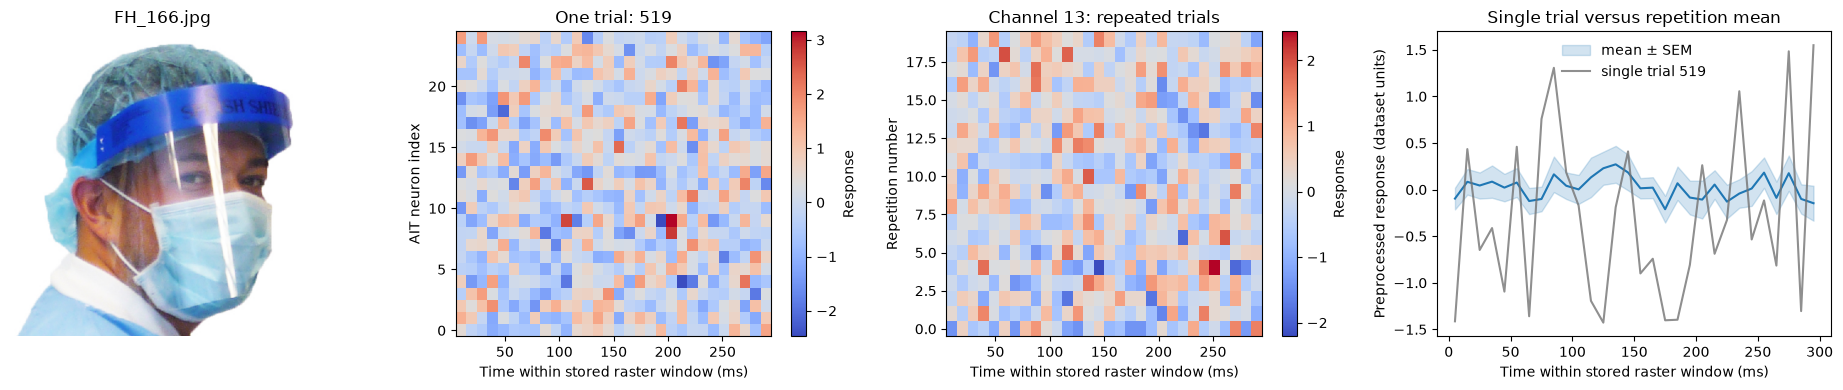

In [39]:
# QUICK SWITCHES: change these two lines, then rerun Section 6 only.
visualization_image_choice: int | str | None = 50
visualization_channel_index: int | None = 13  # e.g. 13

if visualization_image_choice is None:
    visualization_source_image_index = source_image_index
elif isinstance(visualization_image_choice, str):
    matching_image_indices = image_indices_by_filename.get(
        visualization_image_choice, []
    )
    if len(matching_image_indices) != 1:
        raise ValueError(
            f"Expected one represented image named "
            f"{visualization_image_choice!r}; "
            f"found {len(matching_image_indices)}."
        )
    # end if the filename is absent or ambiguous
    visualization_source_image_index = matching_image_indices[0]
else:
    visualization_source_image_index = visualization_image_choice
    if visualization_source_image_index not in image_activity_scores:
        raise ValueError(
            "Visualization image index is not represented in the trials."
        )
    # end if the requested image has no neural trials
# end if the quick visualization override is unused

if visualization_channel_index is None:
    selected_channel_index = neuron_index
else:
    selected_channel_index = visualization_channel_index
    if not 0 <= selected_channel_index < raster_array.shape[0]:
        raise IndexError(
            "visualization_channel_index is outside the selected area."
        )
    # end if the requested channel is invalid
# end if the quick channel override is unused

visualization_repeat_trial_indices = np.flatnonzero(
    image_indices == visualization_source_image_index
)
visualization_trial_index = int(visualization_repeat_trial_indices[0])
visualization_image_path = Path(
    image_dataset.samples[visualization_source_image_index][0]
)
visualization_image, visualization_target = paired_dataset[
    visualization_trial_index
]

repeated_responses = raster_array[selected_channel_index][
    :, visualization_repeat_trial_indices
].T  # [repetitions, time]
repeat_mean = repeated_responses.mean(axis=0)
repeat_sem = repeated_responses.std(axis=0, ddof=1) / np.sqrt(
    len(repeated_responses)
)
population_response = visualization_target.numpy().T  # [neurons, time]

figure, axes = plt.subplots(1, 4, figsize=(19, 4))
image_for_plot = visualization_image.permute(1, 2, 0).numpy()
axes[0].imshow(np.clip(image_for_plot, 0, 1))
axes[0].set_title(visualization_image_path.name)
axes[0].axis("off")

population_plot = axes[1].imshow(
    population_response, aspect="auto", origin="lower",
    extent=[binned_time_ms[0], binned_time_ms[-1], -0.5,
            population_response.shape[0] - 0.5],
    cmap="coolwarm",
)
axes[1].set_xlabel("Time within stored raster window (ms)")
axes[1].set_ylabel(f"{cfg.brain_area} neuron index")
axes[1].set_title(f"One trial: {visualization_trial_index}")
figure.colorbar(population_plot, ax=axes[1], label="Response")

repeat_plot = axes[2].imshow(
    repeated_responses, aspect="auto", origin="lower",
    extent=[binned_time_ms[0], binned_time_ms[-1], -0.5,
            len(repeated_responses) - 0.5],
    cmap="coolwarm",
)
axes[2].set_xlabel("Time within stored raster window (ms)")
axes[2].set_ylabel("Repetition number")
axes[2].set_title(
    f"Channel {selected_channel_index}: repeated trials"
)
figure.colorbar(repeat_plot, ax=axes[2], label="Response")

axes[3].plot(binned_time_ms, repeat_mean, color="tab:blue")
axes[3].fill_between(
    binned_time_ms, repeat_mean - repeat_sem, repeat_mean + repeat_sem,
    color="tab:blue", alpha=0.2, label="mean ± SEM",
)
axes[3].plot(
    binned_time_ms,
    visualization_target[:, selected_channel_index].numpy(),
    color="0.45", alpha=0.8,
    label=f"single trial {visualization_trial_index}",
)
axes[3].set_xlabel("Time within stored raster window (ms)")
axes[3].set_ylabel("Preprocessed response (dataset units)")
axes[3].set_title("Single trial versus repetition mean")
axes[3].legend(frameon=False)
figure.tight_layout()
plt.show()

### Same-image trials for the five most self-consistent channels

The project defines self-consistency with `split_half_reliability`: repetitions of every image are randomly divided in half, each half is averaged, the two stimulus-response profiles are correlated across images, and the correlation is Spearman–Brown corrected. Its square root is the `stim_r` ceiling used by the model's consistency-weighted analyses.

To mirror that protocol, reliability is estimated from the model's seeded 80% training-image split with 40 resamples. The function returns `[time, channel]`; channels are ranked here by their mean ceiling across the complete displayed 0–300 ms window. This ranking is computed across images—it does not select channels for looking good on the example image.

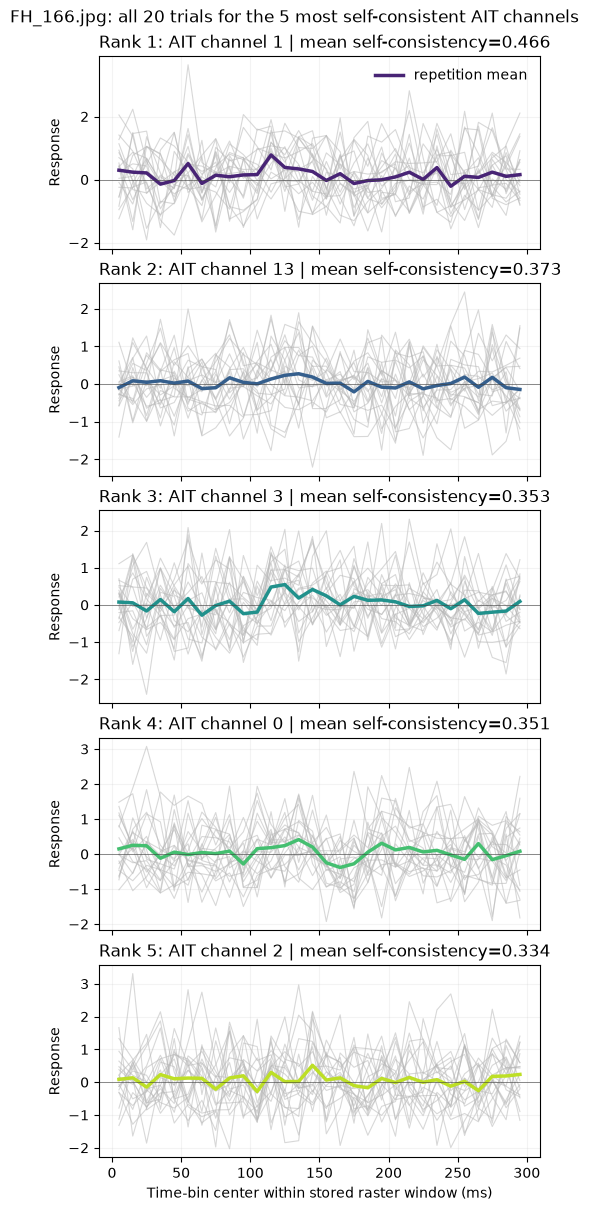

Channel ranking by mean 0--300 ms self-consistency:
  1. channel 1: 0.4661
  2. channel 13: 0.3733
  3. channel 3: 0.3529
  4. channel 0: 0.3513
  5. channel 2: 0.3342


: 

In [ ]:
if not 0.0 < cfg.validation_fraction < 1.0:
    raise ValueError("validation_fraction must be between zero and one.")
# end if the validation fraction is invalid
if not 1 <= cfg.n_consistent_channels <= raster_array.shape[0]:
    raise ValueError("n_consistent_channels exceeds the selected channels.")
# end if the requested channel count is invalid

# Reproduce the model's image-grouped train/validation split.
unique_image_indices = np.unique(image_indices)
n_validation_images = max(
    1, round(len(unique_image_indices) * cfg.validation_fraction)
)
split_generator = np.random.default_rng(cfg.random_seed)
shuffled_unique_images = split_generator.permutation(unique_image_indices)
training_image_indices = shuffled_unique_images[n_validation_images:]
self_consistency_trial_mask = np.isin(
    image_indices, training_image_indices
)

# Keep only image identities with enough repetitions for a split-half.
candidate_images, candidate_counts = np.unique(
    image_indices[self_consistency_trial_mask], return_counts=True
)
eligible_images = candidate_images[candidate_counts >= 2]
self_consistency_trial_mask &= np.isin(image_indices, eligible_images)
selected_image_indices = image_indices[self_consistency_trial_mask]
_, compact_image_ids = np.unique(
    selected_image_indices, return_inverse=True
)
trial_targets = raster_array.transpose(2, 1, 0)  # [trials, time, channels]
selected_trial_targets = trial_targets[self_consistency_trial_mask]

self_consistency_by_time_channel = split_half_reliability(
    trial_targets=selected_trial_targets,
    image_ids=compact_image_ids,
    n_images=len(eligible_images),
    reducer="mean",
    n_resamples=cfg.self_consistency_resamples,
    seed=cfg.random_seed,
)  # [time, channels], sqrt(Spearman-Brown reliability)
channel_self_consistency = np.nanmean(
    self_consistency_by_time_channel, axis=0
)
rankable_self_consistency = np.nan_to_num(
    channel_self_consistency, nan=-np.inf
)
ranked_channel_indices = np.argsort(rankable_self_consistency)[::-1]
top_channel_indices = ranked_channel_indices[: cfg.n_consistent_channels]

# Draw every repetition of the selected image for each ranked channel.
channel_colors = plt.get_cmap("viridis")(
    np.linspace(0.1, 0.9, cfg.n_consistent_channels)
)
figure, axes = plt.subplots(
    cfg.n_consistent_channels, 1, figsize=(5, 12), sharex=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)
for rank, (axis, channel_index, color) in enumerate(
    zip(axes, top_channel_indices, channel_colors), start=1
):
    channel_trial_responses = raster_array[channel_index][
        :, visualization_repeat_trial_indices
    ].T  # [repetitions, time]
    axis.plot(
        binned_time_ms, channel_trial_responses.T,
        color="0.72", alpha=0.55, linewidth=0.8,
    )
    axis.plot(
        binned_time_ms, channel_trial_responses.mean(axis=0),
        color=color, linewidth=2.5, label="repetition mean",
    )
    axis.axhline(0, color="0.25", linewidth=0.7, alpha=0.6)
    axis.set_title(
        f"Rank {rank}: {cfg.brain_area} channel {channel_index} | "
        f"mean self-consistency={channel_self_consistency[channel_index]:.3f}",
        loc="left",
    )
    axis.set_ylabel("Response")
    axis.grid(True, alpha=0.15)
# end for ranked self-consistent channel
axes[0].legend(frameon=False, loc="upper right")
axes[-1].set_xlabel("Time-bin center within stored raster window (ms)")
figure.suptitle(
    f"{visualization_image_path.name}: all "
    f"{len(visualization_repeat_trial_indices)} trials for "
    f"the {cfg.n_consistent_channels} most self-consistent "
    f"{cfg.brain_area} channels"
)
plt.show()

print("Channel ranking by mean 0--300 ms self-consistency:")
for rank, channel_index in enumerate(top_channel_indices, start=1):
    print(
        f"  {rank}. channel {channel_index}: "
        f"{channel_self_consistency[channel_index]:.4f}"
    )
# end for ranked self-consistent channel

### Multiple population responses to the same image

Each panel below is a separate neural presentation paired with the image shown above. The final panel is their average across **all** repetitions. A shared color scale makes trial-to-trial differences visible without changing the meaning of the values between panels.

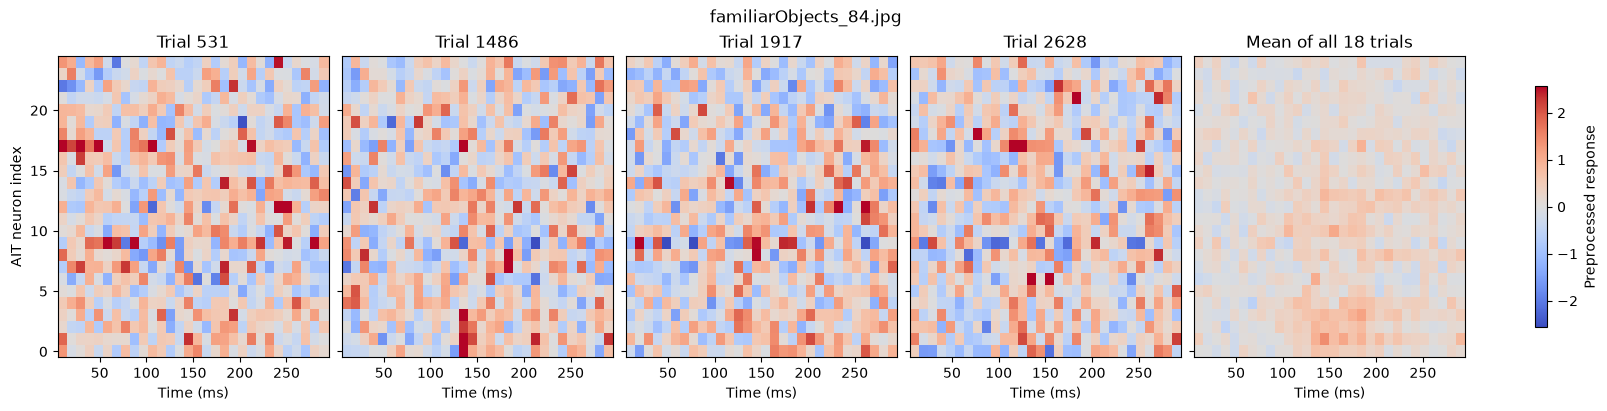

In [11]:
n_repetitions_to_show = min(
    cfg.n_example_repetitions, len(visualization_repeat_trial_indices)
)
shown_trial_indices = visualization_repeat_trial_indices[
    :n_repetitions_to_show
]
repeated_population_responses = np.take(
    raster_array, visualization_repeat_trial_indices, axis=2
)  # [neurons, time, repetitions]
mean_population_response = repeated_population_responses.mean(axis=2)

# Use one robust symmetric scale for every single-trial and mean panel.
response_limit = np.percentile(
    np.abs(repeated_population_responses), 99
)
figure, axes = plt.subplots(
    1, n_repetitions_to_show + 1,
    figsize=(3.2 * (n_repetitions_to_show + 1), 4),
    sharex=True, sharey=True, constrained_layout=True,
)
for axis, repeated_trial_index in zip(axes[:-1], shown_trial_indices):
    image = axis.imshow(
        raster_array[:, :, repeated_trial_index],
        aspect="auto", origin="lower", cmap="coolwarm",
        vmin=-response_limit, vmax=response_limit,
        extent=[binned_time_ms[0], binned_time_ms[-1], -0.5,
                raster_array.shape[0] - 0.5],
    )
    axis.set_title(f"Trial {repeated_trial_index}")
    axis.set_xlabel("Time (ms)")
# end for selected repetition

axes[-1].imshow(
    mean_population_response,
    aspect="auto", origin="lower", cmap="coolwarm",
    vmin=-response_limit, vmax=response_limit,
    extent=[binned_time_ms[0], binned_time_ms[-1], -0.5,
            raster_array.shape[0] - 0.5],
)
axes[-1].set_title(
    f"Mean of all {len(visualization_repeat_trial_indices)} trials"
)
axes[-1].set_xlabel("Time (ms)")
axes[0].set_ylabel(f"{cfg.brain_area} neuron index")
figure.colorbar(image, ax=axes, label="Preprocessed response", shrink=0.8)
figure.suptitle(visualization_image_path.name)
plt.show()

## 7. What the DataLoader adds

`make_neural_input_loader` wraps the paired dataset and stacks samples into batches. With `shuffle=False`, batch 0 contains trials `0:batch_size`, which makes the comparison easy to audit. With `shuffle=True`, sample order changes, but each image-target pair remains intact.

For train/validation splitting with repeated rasters, split by **unique image identity** and then assign all corresponding trial indices to that partition. Splitting trial indices directly leaks repetitions of the same image across partitions.

In [12]:
loader = make_neural_input_loader(
    input_mode="images",
    image_dataset=image_dataset,
    activations=None,
    neural_activity=raster_array,
    image_indices=image_indices,
    batch_size=cfg.batch_size,
    shuffle=False,
    pin_memory=False,
)
image_batch, target_batch = next(iter(loader))
expected_first_batch = torch.as_tensor(
    raster_array[:, :, : cfg.batch_size].transpose(2, 1, 0),
    dtype=torch.float32,
)
torch.testing.assert_close(target_batch, expected_first_batch, rtol=0, atol=0)

print(f"image batch [batch, RGB, height, width]: {tuple(image_batch.shape)}")
print(f"target batch [batch, time, neurons]: {tuple(target_batch.shape)}")
print("PASS: the unshuffled first batch contains raster trials 0:batch_size.")

image batch [batch, RGB, height, width]: (8, 3, 500, 500)
target batch [batch, time, neurons]: (8, 30, 25)
PASS: the unshuffled first batch contains raster trials 0:batch_size.


## 8. Optional: compare repeated-trial mean with `natraster`

`natraster` contains one response per unique image, whereas `raster` contains repeated presentations. The following comparison aligns both through the same `ImageFolder` identity and compares the selected neuron's repetition mean.

Do not require exact equality here: the repeated file name spans sessions `250313to21`, while the averaged file is named for `250313`, and the source preprocessing/provenance may differ. This section is a scientific comparison; Section 5 was the exact implementation audit. When optional neural preprocessing is enabled, the repeated-raster statistics are reused for `natraster` so both traces remain on the same scale.

In [ ]:
# The next cell loads natraster before using or plotting its values.

In [ ]:
natraster = load_img_natraster(
    paths=paths,
    monkey_name=cfg.monkey_name,
    date=cfg.natraster_date,
    new_fs=cfg.new_fs,
    brain_area=cfg.brain_area,
    original_fs=cfg.original_fs,
    time_start_ms=cfg.time_start_ms,
    time_end_ms=cfg.time_end_ms,
)
raw_natraster_array = natraster.get_array()
natraster_array = apply_neural_preprocessing(
    raw_natraster_array,
    neural_preprocessing_stats,
)
natraster_image_indices = np.asarray(
    map_image_order_from_ann_to_monkey(
        paths, cfg.monkey_name, cfg.natraster_date, image_dataset
    ),
    dtype=int,
)
natraster_positions = np.flatnonzero(
    natraster_image_indices == source_image_index
)
if len(natraster_positions) != 1:
    raise ValueError("Expected exactly one natraster row for the image.")
# end if the unique-image alignment is ambiguous
natraster_position = int(natraster_positions[0])
averaged_response = natraster_array[
    neuron_index, :, natraster_position
]
selected_correlation = np.corrcoef(repeat_mean, averaged_response)[0, 1]

plt.figure(figsize=(7, 4))
plt.plot(
    binned_time_ms, repeat_mean, color="tab:blue",
    label=f"mean of {len(repeated_responses)} repeated raster trials",
)
plt.plot(
    binned_time_ms, averaged_response, color="tab:orange",
    linestyle="--", label="natraster unique-image response",
)
plt.xlabel("Time within stored raster window (ms)")
plt.ylabel("Preprocessed response (dataset units)")
plt.title(f"Selected-trace correlation: {selected_correlation:.3f}")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## 9. Collect the exact model-DataLoader tensors and average repetitions

Static-to-dynamic RSA needs one neural representation per image and time bin. For image identity $i$, neuron $n$, and time bin $t$, we compute

$$
\bar{R}_{n,t,i} = \frac{1}{K_i} \sum_{k=1}^{K_i} R_{n,t,i,k}.
$$

The current model configuration uses `training_input_mode="activations"`, so the model DataLoader returns cached DINO features `[batch, selected_layers, embedding]` together with neural targets `[batch, time, neurons]`. The four configured layers below match `baseline_model_dev.ipynb`.

For an auditable pass, `shuffle=False` preserves trial order. This does not change any sample: the training loader's `shuffle=True` only changes the order in which the same image-feature/target pairs are visited. We accumulate both sides directly from DataLoader batches and group them with the corresponding trial-to-image indices. No activation file is read by the dRSA calculation itself.

In [14]:
if cfg.training_input_mode != "activations":
    raise ValueError(
        "This audit expects the model's current activation-input mode."
    )
# end if the configured model input mode differs

n_images = len(image_dataset)
layer_names = list(cfg.model_layer_names)
precomputed_layer_features = load_hf_layer_features(
    output_dir=Path(paths["data_path"]) / "models",
    dataset_name=cfg.folder_name,
    model_name=cfg.model_name,
    img_size=cfg.model_img_size,
    layer_names=layer_names,
    pooling=cfg.model_pooling,
)  # [images, selected layers, embedding]

model_loader = make_neural_input_loader(
    input_mode=cfg.training_input_mode,
    image_dataset=image_dataset,
    activations=precomputed_layer_features,
    neural_activity=raster_array,
    image_indices=image_indices,
    batch_size=cfg.model_batch_size,
    shuffle=False,  # audit order; model training may safely shuffle pairs
    pin_memory=False,
)

repetition_counts = np.bincount(image_indices, minlength=n_images)
if np.any(repetition_counts == 0):
    missing_indices = np.flatnonzero(repetition_counts == 0)
    raise ValueError(
        f"Neural raster has no trials for image indices {missing_indices[:10]}."
    )
# end if an ImageFolder stimulus has no neural trials

# Accumulate exactly what the model loader yields, grouped by image identity.
feature_sums = np.zeros(precomputed_layer_features.shape, dtype=np.float64)
target_sums = np.zeros(
    (n_images, raster_array.shape[1], raster_array.shape[0]),
    dtype=np.float64,
)
loader_repetition_counts = np.zeros(n_images, dtype=int)
maximum_feature_difference = 0.0
maximum_target_difference = 0.0
trial_start = 0

for feature_batch, target_batch in model_loader:
    feature_batch = feature_batch.numpy()
    target_batch = target_batch.numpy()
    trial_end = trial_start + len(feature_batch)
    batch_image_indices = image_indices[trial_start:trial_end]

    # Prove that these are the exact feature/response pairs indexed by trials.
    expected_feature_batch = precomputed_layer_features[batch_image_indices]
    expected_target_batch = raster_array[
        :, :, trial_start:trial_end
    ].transpose(2, 1, 0)
    maximum_feature_difference = max(
        maximum_feature_difference,
        float(np.max(np.abs(feature_batch - expected_feature_batch))),
    )
    maximum_target_difference = max(
        maximum_target_difference,
        float(np.max(np.abs(target_batch - expected_target_batch))),
    )

    for image_index in np.unique(batch_image_indices):
        belongs_to_image = batch_image_indices == image_index
        feature_sums[image_index] += feature_batch[belongs_to_image].sum(axis=0)
        target_sums[image_index] += target_batch[belongs_to_image].sum(axis=0)
        loader_repetition_counts[image_index] += belongs_to_image.sum()
    # end for image identity in the current batch
    trial_start = trial_end
# end for model DataLoader batch

if trial_start != raster_array.shape[2]:
    raise RuntimeError("The model DataLoader did not visit every neural trial.")
# end if the audit pass is incomplete
np.testing.assert_array_equal(loader_repetition_counts, repetition_counts)

mean_model_features_by_image = (
    feature_sums / loader_repetition_counts[:, None, None]
).astype(np.float32)  # [images, layers, embedding]
mean_loader_targets_by_image = (
    target_sums / loader_repetition_counts[:, None, None]
).astype(np.float32)  # [images, time, neurons]
mean_neural_by_image = mean_loader_targets_by_image.transpose(2, 1, 0)

np.testing.assert_allclose(
    mean_neural_by_image[:, :, source_image_index],
    mean_population_response, rtol=1e-6, atol=1e-6,
)

print(f"model-loader features [images, layers, embedding]: "
      f"{mean_model_features_by_image.shape}")
print(f"model-loader neural means [neurons, time, images]: "
      f"{mean_neural_by_image.shape}")
print(
    f"repetitions per image: {repetition_counts.min()}--"
    f"{repetition_counts.max()} (mean {repetition_counts.mean():.2f})"
)
print(f"maximum feature-batch difference: {maximum_feature_difference:.3e}")
print(f"maximum target-batch difference: {maximum_target_difference:.3e}")
print("PASS: dRSA inputs were collected from exact model-DataLoader pairs.")

model-loader features [images, layers, embedding]: (776, 4, 1024)
model-loader neural means [neurons, time, images]: (25, 30, 776)
repetitions per image: 16--23 (mean 19.12)
maximum feature-batch difference: 0.000e+00
maximum target-batch difference: 0.000e+00
PASS: dRSA inputs were collected from exact model-DataLoader pairs.


## 10. Static DNN layers × dynamic neural-time dRSA

For neural time $t$ and static DNN layer $\ell$, the analysis is

$$
\operatorname{dRSA}(t, \ell) = \rho_{\mathrm{Spearman}}\left(
\operatorname{vec} D_{\mathrm{neural}}(t),
\operatorname{vec} D_{\mathrm{DNN}}(\ell)
\right).
$$

Each RDM contains all pairwise image dissimilarities. The configured `cosine_cnt` metric first centers every response feature across images and then computes cosine dissimilarity. Spearman RSA compares the ranks of the two RDM vectors. No neural-to-DNN regression is fitted.

The dRSA inputs below are constructed only from the batches returned by `model_loader`. The four DINOv3-L layers are exactly the layers configured for the current baseline model: depths 3, 13, 16, and 20. The batch audit checks every returned feature and neural target against the trial mapping before averaging. A fixed shuffled-association control then breaks only the cross-modal image identity; one shuffle is illustrative, not a significance test.

In [15]:
# Convert the averaged tensors collected from model_loader to dRSA axes.
features_by_layer = {
    layer_name: mean_model_features_by_image[:, layer_index, :].T
    for layer_index, layer_name in enumerate(layer_names)
}  # each value is [embedding, images]

for layer_name, layer_features in features_by_layer.items():
    if layer_features.shape[1] != mean_neural_by_image.shape[2]:
        raise ValueError(
            f"Layer {layer_name!r} and neural responses have different "
            "image counts."
        )
    # end if one model-loader layer and neural targets do not align
# end for model-loader feature layer

print("Correct image association:")
drsa, best_layer_indices, best_layer_names = compute_static_drsa(
    target_features=mean_neural_by_image,
    times=binned_time_ms,
    features_by_layer=features_by_layer,
    signal_rdm_metric=cfg.signal_RDM_metric,
    model_rdm_metric=cfg.model_RDM_metric,
    rsa_metric=cfg.RSA_metric,
)

# Break only the neural-to-image association while preserving both datasets.
random_generator = np.random.default_rng(cfg.alignment_shuffle_seed)
shuffled_image_order = random_generator.permutation(n_images)
print("\nShuffled image association control:")
shuffled_drsa, _, _ = compute_static_drsa(
    target_features=mean_neural_by_image[:, :, shuffled_image_order],
    times=binned_time_ms,
    features_by_layer=features_by_layer,
    signal_rdm_metric=cfg.signal_RDM_metric,
    model_rdm_metric=cfg.model_RDM_metric,
    rsa_metric=cfg.RSA_metric,
)

print(f"\nDNN layers: {len(layer_names)}")
print(f"aligned dRSA [neural time, DNN layer]: {drsa.shape}")
print(f"aligned peak dRSA: {np.nanmax(drsa):.4f}")
print(f"shuffled-control peak dRSA: {np.nanmax(shuffled_drsa):.4f}")

Correct image association:
time=05 best=layer.16.mlp.down_proj dRSA=0.0029
time=15 best=layer.20.mlp.down_proj dRSA=0.0025
time=25 best=layer.20.mlp.down_proj dRSA=-0.0001
time=35 best=layer.20.mlp.down_proj dRSA=-0.0002
time=45 best=layer.20.mlp.down_proj dRSA=0.0048
time=55 best=layer.3.mlp.down_proj dRSA=-0.0005
time=65 best=layer.20.mlp.down_proj dRSA=0.0047
time=75 best=layer.20.mlp.down_proj dRSA=0.0013
time=85 best=layer.20.mlp.down_proj dRSA=0.0047
time=95 best=layer.13.mlp.down_proj dRSA=0.0158
time=105 best=layer.13.mlp.down_proj dRSA=0.0301
time=115 best=layer.13.mlp.down_proj dRSA=0.0524
time=125 best=layer.13.mlp.down_proj dRSA=0.0594
time=135 best=layer.13.mlp.down_proj dRSA=0.0710
time=145 best=layer.16.mlp.down_proj dRSA=0.0737
time=155 best=layer.16.mlp.down_proj dRSA=0.0697
time=165 best=layer.16.mlp.down_proj dRSA=0.1118
time=175 best=layer.16.mlp.down_proj dRSA=0.1179
time=185 best=layer.16.mlp.down_proj dRSA=0.1183
time=195 best=layer.16.mlp.down_proj dRSA=0.1004
t

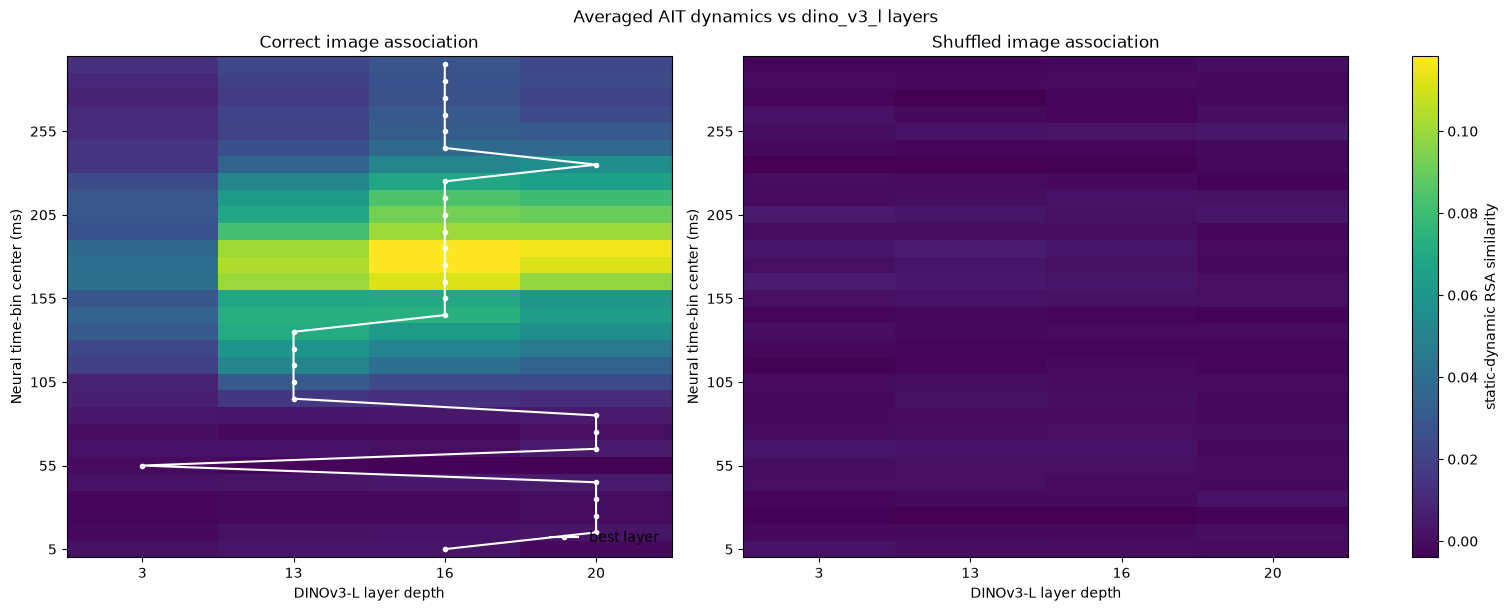

In [16]:
# Match the project's DNN-dynamics heatmap convention: time × layer.
common_vmin = np.nanmin([drsa.min(), shuffled_drsa.min()])
common_vmax = np.nanmax([drsa.max(), shuffled_drsa.max()])
time_tick_indices = np.arange(0, len(binned_time_ms), 5)
layer_tick_indices = np.arange(len(layer_names))
layer_tick_labels = [name.split(".")[1] for name in layer_names]

figure, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
for axis, matrix, title in zip(
    axes,
    [drsa, shuffled_drsa],
    ["Correct image association", "Shuffled image association"],
):
    heatmap = axis.imshow(
        matrix, aspect="auto", origin="lower",
        cmap=cfg.heatmap_cmap, vmin=common_vmin, vmax=common_vmax,
    )
    axis.set_xlabel("DINOv3-L layer depth")
    axis.set_ylabel("Neural time-bin center (ms)")
    axis.set_xticks(layer_tick_indices)
    axis.set_xticklabels(layer_tick_labels)
    axis.set_yticks(time_tick_indices)
    axis.set_yticklabels(binned_time_ms[time_tick_indices].astype(int))
    axis.set_title(title)
# end for aligned and shuffled dRSA heatmap

axes[0].plot(
    best_layer_indices, np.arange(len(binned_time_ms)),
    color="white", marker="o", linewidth=1.5, markersize=3,
    label="best layer",
)
axes[0].legend(frameon=False, loc="lower right")
figure.colorbar(heatmap, ax=axes, label="static-dynamic RSA similarity")
figure.suptitle(
    f"Averaged {cfg.brain_area} dynamics vs {cfg.model_name} layers"
)
plt.show()

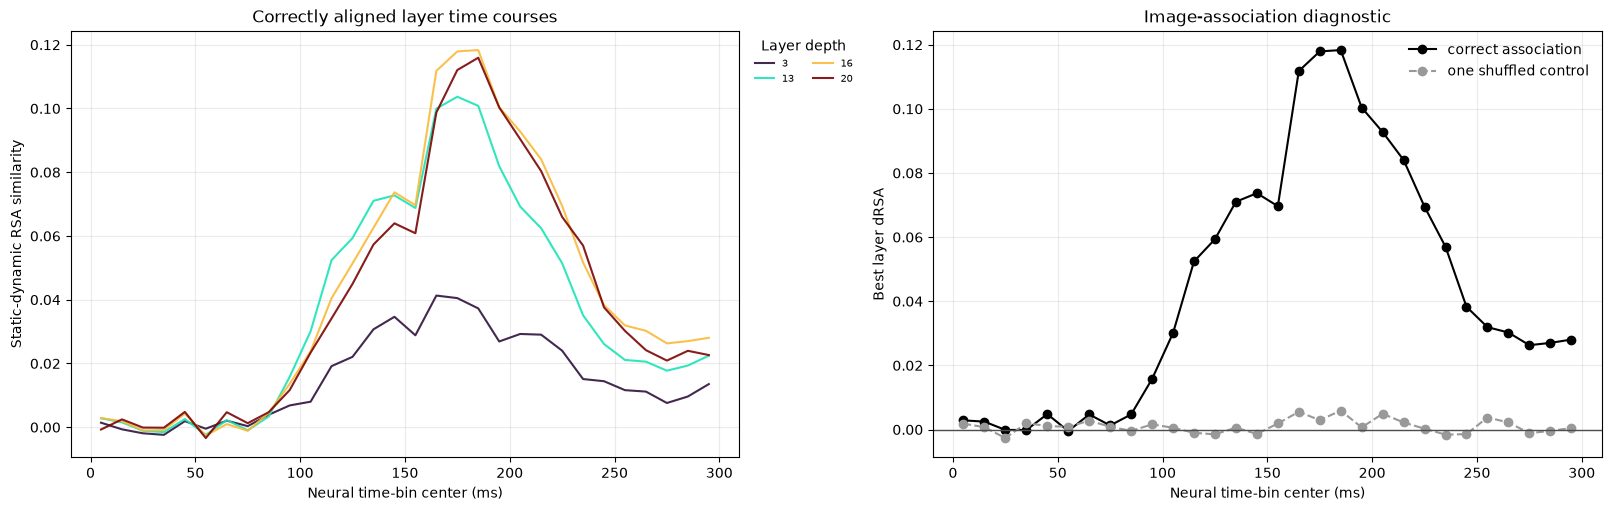

Layer-depth lookup:
  00: layer.3.mlp.down_proj
  01: layer.13.mlp.down_proj
  02: layer.16.mlp.down_proj
  03: layer.20.mlp.down_proj


In [17]:
# Plot every layer as a neural-time curve, colored from early to late depth.
layer_colors = plt.get_cmap(cfg.layer_line_cmap)(
    np.linspace(0, 1, len(layer_names))
)
figure, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
for layer_index, (layer_name, color) in enumerate(
    zip(layer_names, layer_colors)
):
    axes[0].plot(
        binned_time_ms, drsa[:, layer_index], color=color,
        linewidth=1.5, alpha=0.9, label=layer_name.split(".")[1],
    )
# end for DNN layer
axes[0].set_xlabel("Neural time-bin center (ms)")
axes[0].set_ylabel("Static-dynamic RSA similarity")
axes[0].set_title("Correctly aligned layer time courses")
axes[0].grid(True, alpha=0.25)
axes[0].legend(
    title="Layer depth", ncol=2, fontsize=7, frameon=False,
    bbox_to_anchor=(1.01, 1), loc="upper left",
)

aligned_best_by_time = np.nanmax(drsa, axis=1)
shuffled_best_by_time = np.nanmax(shuffled_drsa, axis=1)
axes[1].plot(
    binned_time_ms, aligned_best_by_time, color="black",
    marker="o", label="correct association",
)
axes[1].plot(
    binned_time_ms, shuffled_best_by_time, color="0.6",
    marker="o", linestyle="--", label="one shuffled control",
)
axes[1].axhline(0, color="0.3", linewidth=1)
axes[1].set_xlabel("Neural time-bin center (ms)")
axes[1].set_ylabel("Best layer dRSA")
axes[1].set_title("Image-association diagnostic")
axes[1].grid(True, alpha=0.25)
axes[1].legend(frameon=False)
plt.show()

print("Layer-depth lookup:")
for layer_index, layer_name in enumerate(layer_names):
    print(f"  {layer_index:02d}: {layer_name}")
# end for DNN layer

## Take-home interpretation

- A dataset index denotes a **neural presentation**, not a unique image.
- `image_indices[i]` selects the image or cached activation paired with presentation `i`.
- The target returned for presentation `i` is `raster_array[:, :, i].T`: `[time, neurons]`.
- Optional preprocessing first centers each neuron-time feature across fitting samples, then robustly min-max scales each neuron using its configured percentiles.
- The repeated raster's trial variability is preserved. Averaging happens only across source time samples during downsampling, not across trials.
- The five channel-trace panels are ordered by training-image split-half self-consistency averaged over neural time, not by their response to the displayed image.
- `time_start_ms` is an offset within the stored raster array. Interpret it as time from stimulus onset only if that convention is confirmed by the recording metadata.
- When using cached ANN activations, their first axis must remain in exactly the same `ImageFolder` order used to construct `image_indices`.
- The dRSA section streams feature/target pairs from the same `NeuralInputDataset` configuration used by the model, verifies every batch, and only then averages repetitions by image identity.
- Static-to-dynamic RSA compares image geometry at every neural time bin with image geometry at every DNN layer; it does not fit a predictive mapping.
- A shuffled association is a useful alignment control, but a single shuffle is not a permutation-based significance test.

The exact raw-to-target assertion in Section 5 is the key debugging check to keep when adapting the loader to another monkey, brain area, time window, or sampling rate.